# Training noise-robust models via augmenting the train dataset

## 1. Data loading

First, we load the annotated dataset, which has been split into training, validation, and test sets (approximately 60/20/20). The training set is used to train the model, the test set is used to evaluate its performance under different scenarios, and the validation set is used to select the best training setup (i.e., tune model or training parameters). This separation helps prevent data leakage and makes parameter tuning more statistically robust.

For the further analysis, the data is loaded in a dictionary *all_splits_dict*, where a key corresponds to a split ID, and each value si another dictionary with train/validation/test X and y data. I.e.

all_splits_dict = {'0': {"X_train": ..., "y_train": ...,"X_test": ..., "y_test": ...,"X_val": ..., "y_val": ...,}, ...}, where each X/y is represented as a tensor.

In the script below, this data dictionary is created by loading already existing files with the splits. Note, that for the analysis below, it's better to use the evolutionary distant splits (used "phylum level" for the example below).


In [1]:
import os
import torch

# Define constant params that are used below
TAX_LEVEL = "phylum" # <----------------- taxonomy level for train/test split is here!! (used to specify the right directory to read the train/test data from)
DATA_DIRECTORY = f"../../data_diderm/input_data_train_val_test/{TAX_LEVEL}"  # <-------- input data directory is here, specify yours!!
NUM_SPLITS_TO_READ = 30  # <-------------- number of splits to read and process is here!!

RANDOM_SEED = 42
OUTPUT_DIRECTORY = f"outputs/{TAX_LEVEL}"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Make sure the output directories exist
os.makedirs(OUTPUT_DIRECTORY, exist_ok=True)
os.makedirs(f"{OUTPUT_DIRECTORY}/plots", exist_ok=True)

In [3]:
from tqdm import tqdm
from collections import defaultdict

all_splits_dict = defaultdict(int)
for split_id in tqdm(range(NUM_SPLITS_TO_READ), desc="Processing splits..."):
    # Read train data
    data_filename_train = f"{DATA_DIRECTORY}/train_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_train = f"{DATA_DIRECTORY}/train_annot_{TAX_LEVEL}_split_{split_id}"
  #  taxa_names_filename_train = f"{DATA_DIRECTORY}/train_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None
    X_val_train = torch.load(data_filename_train)
    y_label_train = torch.load(y_filename_train)
    # with open(taxa_names_filename_train, "r") as f:
    #     taxa_group_names_train = [line.strip() for line in f]

    # Read validation data
    data_filename_val = f"{DATA_DIRECTORY}/val_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_val = f"{DATA_DIRECTORY}/val_annot_{TAX_LEVEL}_split_{split_id}"
  #  taxa_names_filename_val = f"{DATA_DIRECTORY}/val_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None
    X_val_val = torch.load(data_filename_val)
    y_label_val = torch.load(y_filename_val)
    # with open(taxa_names_filename_val, "r") as f:
    #     taxa_group_names_val = [line.strip() for line in f]

    # Read test data
    data_filename_test = f"{DATA_DIRECTORY}/test_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_test = f"{DATA_DIRECTORY}/test_annot_{TAX_LEVEL}_split_{split_id}"
   # taxa_names_filename_test = f"{DATA_DIRECTORY}/test_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None
    X_val_test = torch.load(data_filename_test)
    y_label_test = torch.load(y_filename_test)
    # with open(taxa_names_filename_test, "r") as f:
    #     taxa_group_names_test = [line.strip() for line in f]
    
    if sum(y_label_train)/len(y_label_train) < 0.01 or  sum(y_label_test)/len(y_label_test) < 0.01:
        print(f"Skipping split_id = {split_id}")
        continue

    if TAX_LEVEL == "random":
        taxa_group_names_train = None
        taxa_group_names_test = None

    if X_val_train is not None and y_label_train is not None and X_val_test is not None and y_label_test is not None and X_val_val is not None and y_label_val is not None:
        curr_split_dict = defaultdict(str)
        curr_split_dict["X_train"] = X_val_train
        curr_split_dict["y_train"] = y_label_train
     #   curr_split_dict["taxa_group_names_train"] = taxa_group_names_train
        curr_split_dict["X_test"] = X_val_test
        curr_split_dict["y_test"] = y_label_test
      #  curr_split_dict["taxa_group_names_test"] = taxa_group_names_test
        curr_split_dict["X_val"] = X_val_val
        curr_split_dict["y_val"] = y_label_val
     #   curr_split_dict["taxa_group_names_val"] = taxa_group_names_val
       # curr_split_dict["feature_names"] = X_column_names

        all_splits_dict[split_id] = curr_split_dict

print(f"Number of added splits = {len(all_splits_dict.keys())}")            

Processing splits...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:01<00:00, 24.74it/s]

Number of added splits = 30


## 2. Noise tolerance of the original model

Here, we train XGBoost models on clean training data (referred to as "original trained models") and evaluate them on test data with gradually increasing levels of noise. This analysis helps assess how well the originally trained models tolerate different noise levels in the test data and identify the point at which model accuracy begins to decline substantially. These results serve as the baseline performance that we will aim to improve in subsequent analyses by training models that are more robust to noise. 

The noise in the test data is implemented in the following way (the noise implementation functions are hidden in *eval_trained_models_on_noisy_data* below):
1. Some fraction of positive counts in a test genome are either decreased by 1 or flipped to 0 (this is defined by *hard_fn_flag* below).
2. Some fraction of all counts are increased by 1.

Those fractions are denoted as $r_{FP}$, and $r_{FN}$ in the plot below.  $r_{FN}$ ranges from 0 to 1, and $r_{FP}$ ranges from 0 to 0.2.

In [4]:
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier

# Train models on the original clean datasets, and save them to a dict
trained_models = {}
for split_id in tqdm(all_splits_dict.keys(), desc="Training splits"):
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]

    pipe = make_pipeline(
        make_pipeline(XGBClassifier(n_jobs=THREADS if DEVICE == "cpu" else None, tree_method="gpu_hist" if DEVICE == "cpu" else "hist"))
    )
    pipe.fit(X_val_train.cpu(), y_label_train.cpu())
    trained_models[split_id] = pipe

Training splits: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:05<00:00,  5.23it/s]


In [5]:
from utils.utils_ancestral_predict import eval_trained_models_on_noisy_data

# Evaluate the original model performance on the test data with gradually added noise
cog_remov_add_accuracies_orig_models = eval_trained_models_on_noisy_data(all_splits_dict, trained_models, hard_fn_flag = True, test_or_val = "test")

In [6]:
def plot_one_accur_measure(ax, accuracy_measure, cog_remov_add_accuracies, alpha=1):
    """
    Plots the accuracies of the original model tested on the test data with gradually added noise.
    """
    cog_remov_add_accuracies_one_measure = defaultdict()
    for key in cog_remov_add_accuracies.keys():
        cog_remov_add_accuracies_one_measure[key] = cog_remov_add_accuracies[key][accuracy_measure]
    
    rem_rates = sorted(set(k[0] for k in cog_remov_add_accuracies_one_measure.keys()))
    add_rates = sorted(set(k[1] for k in cog_remov_add_accuracies_one_measure.keys()))
  #  add_rates = [0.0, 0.05, 0.1]  <------ you can select FP rates for the plot
    
    cmap = plt.cm.tab10
    colors = [cmap(i / (len(rem_rates)-1)) for i in range(len(rem_rates))]

    for i, ar in enumerate(add_rates):
        means = []
        stds = []
        rem_rate_values = []
        for rr in rem_rates:
            key = (rr, ar)
            if key in cog_remov_add_accuracies_one_measure:
                mean, std = cog_remov_add_accuracies_one_measure[key]
                means.append(mean)
                stds.append(std)
                rem_rate_values.append(rr)
        ax.errorbar(rem_rate_values, means, yerr=stds, label = fr"$r_{{FP}}={ar}$", marker='o', capsize=3, linestyle='-', color=colors[i], alpha=alpha)
    
    ax.set_xlabel(r"$r_{FN}$", fontsize=FONTSIZE)
    ax.tick_params(axis='x', labelsize=FONTSIZE)
    ax.tick_params(axis='y', labelsize=FONTSIZE)

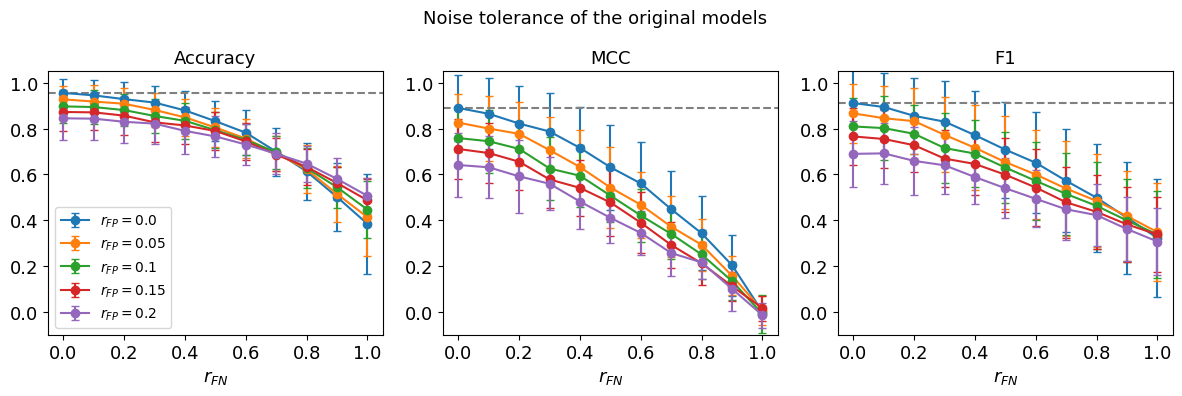

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Visualize the results of the noise handling of the original models

FONTSIZE=13

# Accuracy
fig, axes = plt.subplots(1,3, figsize=(12,4))
plot_one_accur_measure(axes[0], "accuracy", cog_remov_add_accuracies_orig_models)
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['accuracy'][0], color='grey', linestyle='--', linewidth=1.5)
axes[0].set_ylim([-0.1,1.05])
axes[0].set_title("Accuracy", fontsize=FONTSIZE)
axes[0].legend()

# MCC
plot_one_accur_measure(axes[1], "mcc", cog_remov_add_accuracies_orig_models)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['mcc'][0], color='grey', linestyle='--', linewidth=1.5)
axes[1].set_ylim([-0.1,1.05])
axes[1].set_title("MCC", fontsize=FONTSIZE)

# F1
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies_orig_models)
axes[2].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['f1'][0], color='grey', linestyle='--', linewidth=1.5)
axes[2].set_ylim([-0.1,1.05])
axes[2].set_title("F1", fontsize=FONTSIZE)

plt.suptitle(f"Noise tolerance of the original models", fontsize=FONTSIZE)    
plt.tight_layout()

#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/accur_fp_fn.svg", format="svg") <----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_toler_orig_models.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf


## 3. The models trained on noise augmented train data sets (aka noise-robust models)

Here we check the performance of the models trained on noise augmented datasets. The models should be trained and saved to TRAINED_MOD_DIR directory (see and run *train_xgboost_on_noisy_data.py* before running the code below). 

We test multiple noise schemes and choose the one that works the best for our data ("the best" means the one that maximizes the performance on noisy test data).

In each noise scheme we specify the number of noisy genomes $x$ we augment the train data with. Next, we randomly sample FP and FN rates for the noisy genomes. Those rates are sample from either Exponential, or Uniform, or Gamma distributions which are parameterized by their mean values $\lambda_{FP}$, and $\lambda_{FN}$. Therefore, each noise scheme is fully defined by $(x, \lambda_{FP}, \lambda_{FN})$, and the parameter sampling distribution. 

In the examples below, we rank $x$ from 5 to 400;  $\lambda_{FP}$ from 0 to 0.5, and $\lambda_{FN}$ from 0 to 4.

**Important remark:** noise in the test data above is implemented differently from the noise implemented in the augmented train data here. 

In [ ]:
import os
from xgboost import XGBClassifier, XGBRegressor
from sklearn.pipeline import make_pipeline

THREADS = os.cpu_count()
TRAINED_MOD_DIR = "trained_models_train_val_test" #<--------------the name of the directory where the trained models are stored

In [ ]:
def plot_model_groups(noise_increase_accuracy_one_metric, ax, vmin=0.0, vmax=1, cmap="coolwarm", value = "Mean"):
    """
    Plots one pannel of the model accuracy for varying lambda_{FP} and lambda_{FN} values.
    """
    data = []
    for (fp, fn), (mean, std) in noise_increase_accuracy_one_metric.items():
        data.append([fp, fn, mean, std])
    df = pd.DataFrame(data, columns=["FP", "FN", "Mean", "Std"])
    
    pivot = df.pivot(index="FP", columns="FN", values=value)
    pivot = pivot.astype(float) 
    mask = pivot.isna() 
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, vmin=vmin, vmax=vmax, mask=mask, ax=ax, cbar=False)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)


Below, we demonstrate some examples of the distributions what we sample FP and FN rates from.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, uniform, gamma

def exp_pdf(x, mean):
    """
    Exponential distribution PDF with specified mean.
    """
    return expon.pdf(x, scale=mean)

def unif_pdf(x, mean):
    """
    Uniform distribution PDF with specified mean.
    Range: [0, 2*mean]
    """
    return uniform.pdf(x, loc=0, scale=2 * mean)

def gamma_pdf(x, mean, scale=0.5):
    """
    Gamma distribution PDF with specified mean.
    Scale is fixed to 0.5.
    """
    shape = mean / scale
    return gamma.pdf(x, a=shape, scale=scale)

def compute_and_plot_pdfs(mean):
    y_exp = exp_pdf(x, mean)
    y_unif = unif_pdf(x, mean)
    y_gamma = gamma_pdf(x, mean)
    plt.plot(x, y_exp, label="Exponential")
    plt.plot(x, y_unif, label="Uniform")
    plt.plot(x, y_gamma, label="Gamma")
    plt.title(f"PDFs (mean = {mean})")
    plt.xlabel("Value")

# Plot
plt.figure(figsize=(10, 3))
x = np.linspace(0, 10, 1000)

plt.subplot(1,3,1)
mean = 0.5
compute_and_plot_pdfs(mean)

plt.subplot(1,3,2)
mean = 1.0
compute_and_plot_pdfs(mean)

plt.subplot(1,3,3)
mean = 4.0
compute_and_plot_pdfs(mean)

plt.legend()
plt.tight_layout()
plt.show()

### 3.1. Noise-robust model performance on the clean (original) validation data

We start with examining the performance of the noise-robust models on the clean original validation dataset. 

In the plot below, each cell of the panels corresponds to the model performance trained under a particular noise scheme.

Processing noise rates...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 8569.52it/s]


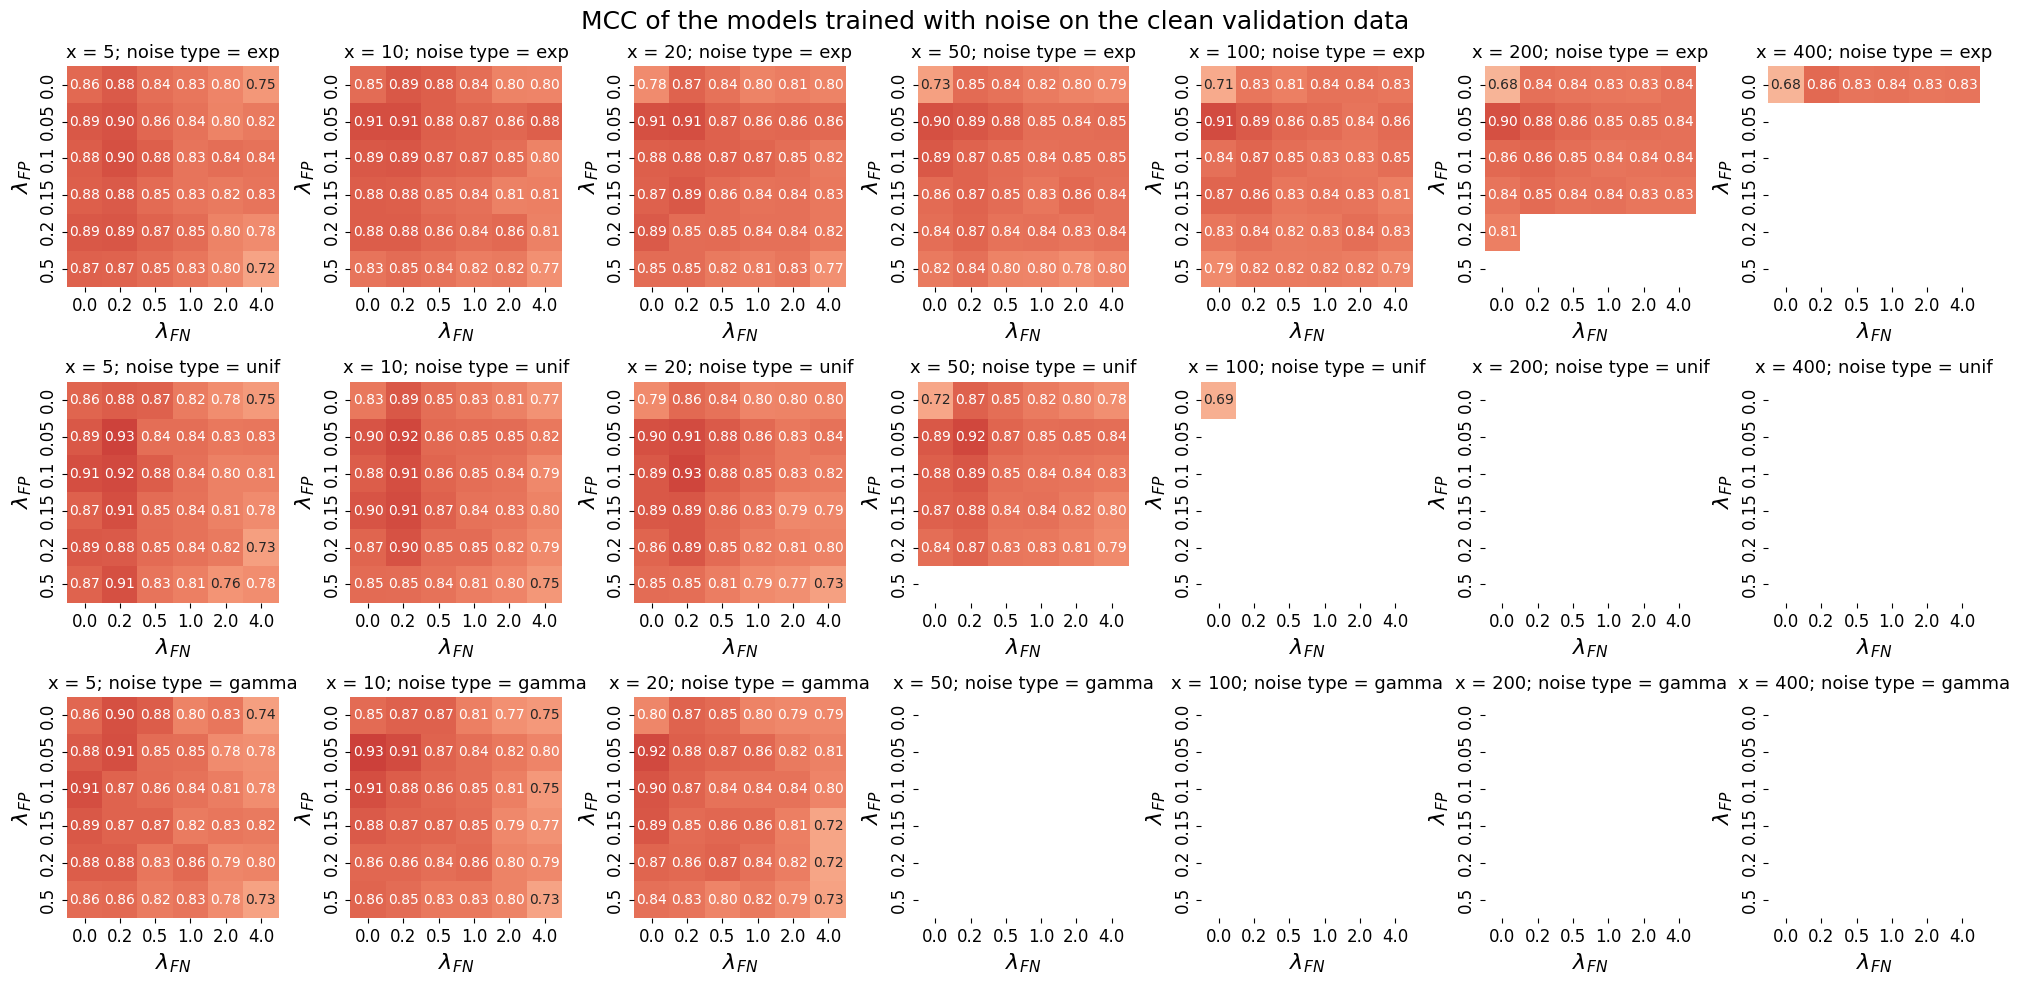

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
from utils.utils_ancestral_predict import  read_and_evaluate_models_for_x_and_sigma

FONTSIZE=13

metric = 'mcc' #<----------specify the metric here
x_range = [5, 10, 20, 50, 100, 200, 400]
noise_type_range = ["exp", "unif", "gamma"]

areas_noise_type_x = {}

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(noise_type_range):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        noise_increase_accuracy_one_metric = read_and_evaluate_models_for_x_and_sigma(TRAINED_MOD_DIR, x, noise_type, metric, all_splits_dict, OUTPUT_DIRECTORY, clean_test_flag = True, add_rate = None, rem_rate = None, noise_std = None, hard_fn_flag = None)

        plot_model_groups(noise_increase_accuracy_one_metric, ax)
        ax.set_title(f"x = {x}; noise type = {noise_type}", fontsize = FONTSIZE)
        ax.set_xlabel(r"$\lambda_{FN}$", fontsize = FONTSIZE+3)
        ax.set_ylabel(r"$\lambda_{FP}$", fontsize = FONTSIZE+3)

plt.suptitle(f"MCC of the models trained with noise on the clean validation data", fontsize=FONTSIZE+5)   
plt.tight_layout()
#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.svg", format="svg") #<----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf       

### 3.2. Noise-robust model performance on the validation data with chosen noise level

Next, we explore how the noise robust models perform on a validation dataset with a chosen level of noise.

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


x_range = [5, 10, 20, 50, 100, 200, 400]
noise_type_range = ["exp", "unif", "gamma"]

test_fp = 0.05 #<------------specify the FP rate here!
test_fn = 0.5 #<------------specify the FN rate here!

Processing noise rates...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 5556.60it/s]


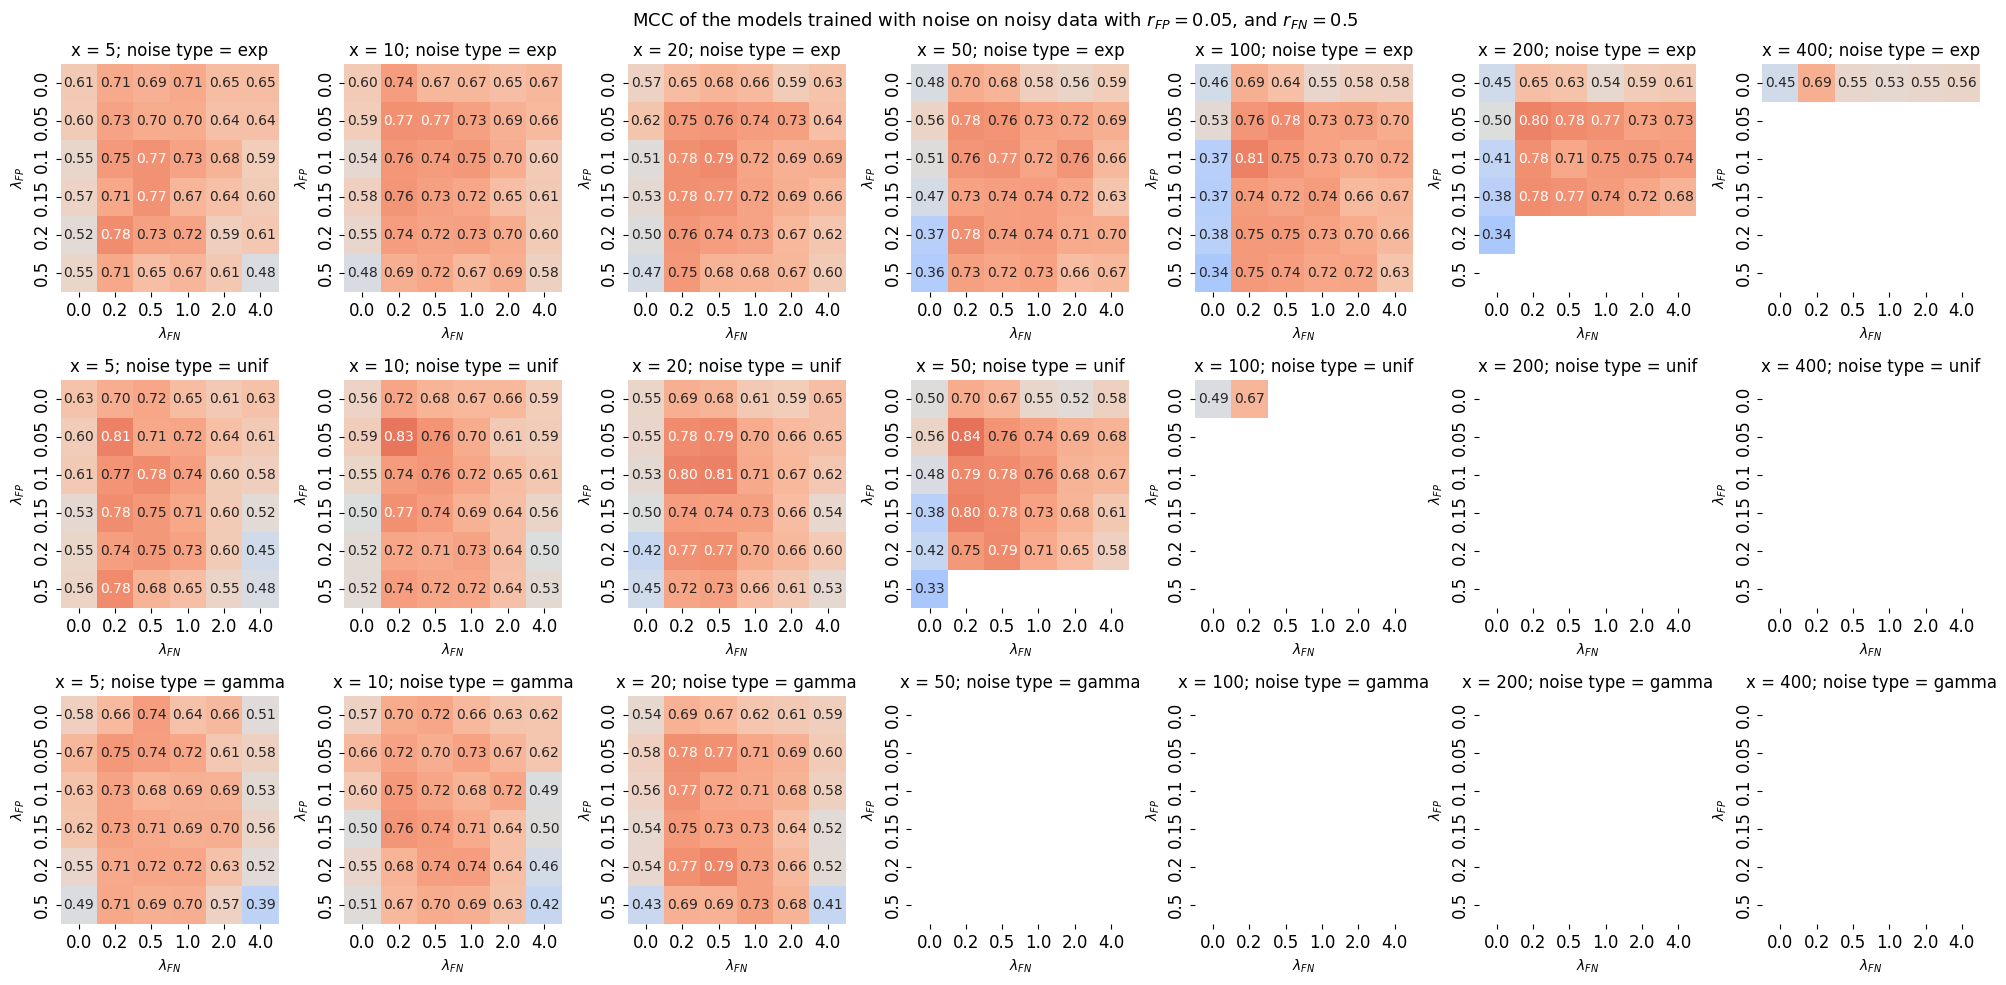

In [13]:
metric = 'mcc'
areas_noise_type_x = {}

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(noise_type_range):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        noise_increase_accuracy_one_metric = read_and_evaluate_models_for_x_and_sigma(TRAINED_MOD_DIR, x, noise_type, metric, all_splits_dict, OUTPUT_DIRECTORY, clean_test_flag = False, add_rate = test_fp, rem_rate = test_fn, noise_std = 0.3, hard_fn_flag = None)
      #  areas_noise_type_x[(x, noise_type)] = areas_mn_std

        plot_model_groups(noise_increase_accuracy_one_metric, ax)
        ax.set_title(f"x = {x}; noise type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"MCC of the models trained with noise on noisy data with $r_{{FP}} = {test_fp}$, and $r_{{FN}} = {test_fn}$", fontsize=FONTSIZE)
plt.tight_layout()

#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.svg", format="svg") #<----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_noisy_test_FP_{test_fp}_FN_{test_fn}_{metric}.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf   

### 3.3. Noise-robust model performance on the validation data across the wide noise range [0, max_fp], [0, max_fn]

Here, we explore how the noise robust models perform across the range of noises to choose the best model.

To quantify these results, we calculate an integral of each FN curve, and find the mean and the std of those integrals across different FP values (see the plot in Section 2 for better understanding). 

First, we plot the mean intergal values.

In [ ]:
from utils.utils_ancestral_predict import  eval_trained_models_on_noisy_data, fp_curve_areas_one_model

# Specify the parameters of the noise schemes to explore
fp_rate_arr = [0.0, 0.05, 0.1, 0.15, 0.2, 0.5]
fn_rate_arr = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
mean_rem_add_rates_tuples = [(add, rem) for add in fp_rate_arr for rem in fn_rate_arr]

x_range = [5, 10, 20, 50, 100, 200]#, 400]
noise_type_range = ["exp", "unif", "gamma"]

# Specify the range of the FP and FN to include in the integral calculations (we don't have to calculate the integral over the entire FN and FP ranges).
max_fp = 0.2
max_fn = 1

FONTSIZE = 13

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict = f"curve_integrals_max_fp_{max_fp}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict}"

        if os.path.exists(filepath):
            print("Loading the existing dict...")
            one_accur_dict = joblib.load(filepath)
        else:
            one_accur_dict = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data(all_splits_dict, loaded_models_dict, hard_fn_flag = True, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'mcc'
                fp_curve_areas = fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict[fp_fn_tuple] = [np.mean(fp_curve_areas), np.std(fp_curve_areas)]

            joblib.dump(one_accur_dict, filepath)
            print("Saving the dict...")

        plot_model_groups(one_accur_dict, ax, vmin=0.2, vmax=0.7, cmap="gnuplot", value = "Mean")
        ax.set_title(f"x = {x}; noise_type = {noise_type}", fontsize = FONTSIZE)
        ax.set_xlabel(r"$\lambda_{FN}$", fontsize = FONTSIZE+3)
        ax.set_ylabel(r"$\lambda_{FP}$", fontsize = FONTSIZE+3)

plt.suptitle(rf"MCC Integral for max_fp = {max_fp}, max_fn = {max_fn}", fontsize=FONTSIZE+5)
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/plots/mcc_integrals_mean_on_noisy_test_{metric}.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf        

Processing noise types:   0%|                                                                                                                                                                         | 0/3 [00:02<?, ?it/s]


In [ ]:
Second, we plot the std intergal values.

In [ ]:
fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict = f"curve_integrals_max_fp_{max_fp}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict}"

        if os.path.exists(filepath):
            print("Loading the existing dict...")
            one_accur_dict = joblib.load(filepath)
        else:
            one_accur_dict = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data(all_splits_dict, loaded_models_dict, hard_fn_flag = True, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'mcc'
                fp_curve_areas = fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict[fp_fn_tuple] = [np.mean(fp_curve_areas), np.std(fp_curve_areas)]

            joblib.dump(one_accur_dict, filepath)
            print("Saving the dict...")


        plot_model_groups(one_accur_dict, ax, vmin=0.0, vmax=0.3, cmap="coolwarm", value = "Std")
       # plot_model_groups(noise_increase_accuracy_one_metric, ax, vmin=0.0, vmax=1, cmap="coolwarm", value = "Std")
       # plot_model_groups(one_accur_dict, ax, vmin=0.3, vmax=0.8, cmap="gnuplot")
        ax.set_title(f"x = {x}; noise_type = {noise_type}", fontsize = FONTSIZE)
        ax.set_xlabel(r"$\lambda_{FN}$", fontsize = FONTSIZE+3)
        ax.set_ylabel(r"$\lambda_{FP}$", fontsize = FONTSIZE+3)

plt.suptitle(rf"MCC Integral std for max_fp = {max_fp}, max_fn = {max_fn}", fontsize=FONTSIZE+5)
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/plots/mcc_integrals_std_on_noisy_test_{metric}.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf    

Our goal is to choose the model that results in a high mean integral value and a low std value (meaning the best performance across FNs and FPs). The choise of the model might not be unique.

In [30]:
# The value of the integral for the perfect model performance on the chose FP and FN ranges
max_fp = 0.2
max_fn = 1
cog_adding_rates = [fp for fp in [0.0, 0.05, 0.1, 0.15, 0.2] if fp <= max_fp]
cog_removal_rates = [fn for fn in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] if fn <= max_fn]
np.trapezoid([1]*len(cog_removal_rates), cog_removal_rates)

np.float64(1.0)

## 4. Visualize the results for the chosen model

In [ ]:
# Choose the parameters of the best model model
x_noisy_samples = 100
fp_rate_mean = 0.1
fn_rate_mean = 0.5
noise_type = "exp"

# Load the trained model
filename = f"trained_models_fp_{fp_rate_mean}_fn_{fn_rate_mean}_noise_type_{noise_type}_x_{x_noisy_samples}.pkl"
loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")

In [ ]:
# Evaluate the accuracy of the chosen model on the test data across different noise ranges
cog_remov_add_accuracies = eval_trained_models_on_noisy_data(all_splits_dict, loaded_models_dict, hard_fn_flag = True, max_fp = 0.2, max_fn = 1, test_or_val = "test")

In [ ]:
# Visualize the results

FONTSIZE=13
metric = 'mcc'

fig, axes = plt.subplots(1,4, figsize=(13,3.5))

plt.subplot(1, 4, 1)
plot_one_accur_measure(axes[0], "balanced_accuracy", cog_remov_add_accuracies)
axes[0].legend()
plot_one_accur_measure(axes[0], "balanced_accuracy", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['balanced_accuracy'][0], color='grey', linestyle='--', linewidth=1.5)
axes[0].set_ylim([-0.1,1.05])
axes[0].set_title("Balanced Accuracy", fontsize=FONTSIZE)

plt.subplot(1, 4, 2)
plot_one_accur_measure(axes[1], "recall", cog_remov_add_accuracies)
plot_one_accur_measure(axes[1], "recall", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['recall'][0], color='grey', linestyle='--', linewidth=1.5)
axes[1].set_ylim([-0.1,1.05])
axes[1].set_title("Recall", fontsize=FONTSIZE)

plt.subplot(1, 4, 3)
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies)
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[2].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['f1'][0], color='grey', linestyle='--', linewidth=1.5)
axes[2].set_ylim([-0.1,1.05])
axes[2].set_title("F1", fontsize=FONTSIZE)


plt.subplot(1, 4, 4)
plot_one_accur_measure(axes[3], "mcc", cog_remov_add_accuracies)
plot_one_accur_measure(axes[3], "mcc", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[3].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['mcc'][0], color='grey', linestyle='--', linewidth=1.5)
axes[3].set_ylim([-0.1,1.05])
axes[3].set_title("MCC", fontsize=FONTSIZE)

plt.suptitle(f"Noise tolerance of the noisy models trained for noise_type = {noise_type}, $\lambda_{{FN}} = {fn_rate_mean}$, $\lambda_{{FP}} = {fp_rate_mean}, x = {x_noisy_samples}$", fontsize=FONTSIZE)
plt.tight_layout()

#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/accur_fp_fn.svg", format="svg") <----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_toler_noisy_model_noise_type_{noise_type}_FP_{fp_rate_mean}_FN_{fn_rate_mean}_x_{x_noisy_samples}_{metric}.svg", format="svg", bbox_inches='tight') #<-------save as pdf

Once we are satisfied with the accuracy of the chosen noise-robust model, it can be applied to prenotype prediction of ancestral genomes. In such a case, a model should be re-trained on the whole dataset of extant genomes augmented with respect to the chosen noise scheme, and then applied to the reconstructed ancestral genomes.

P.S. Let me know if you need my scrips for this part, but they are quite straightforward and use the same functions specified above and in the utils.